In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
git_url="https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/"
films_years=np.arange(1900, 1970, 10)
files_urls=[f'movies-{year}s.json' for year in films_years]

Read each file as a json object.
Get rid of extra columns: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].
Leave only complete rows (rows without missing values).
Combine information from all files into a single dataset.

In [ ]:
dataframes=[]
for file in files_urls:
  file_path=git_url+file
  try:
    df=pd.read_json(file_path)
  except Exception as e:
    print(f'Could not read {file_path}: {e}')
    continue
  drop_columns= ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']
  df=df.drop(columns=drop_columns, errors='ignore')
  df=df.dropna()
  dataframes.append(df)
comb=pd.concat(dataframes, ignore_index=True)
comb.head()


,title,year,cast,genres
0,After Dark in Central Park,1900,[],[]
1,Boarding School Girls' Pajama Parade,1900,[],[]
2,Buffalo Bill's Wild West Parad,1900,[],[]
3,Caught,1900,[],[]
4,Clowns Spinning Hats,1900,[],[Silent]


Check the size of the final dataset

In [ ]:
comb.to_csv('mov_comb.csv', index=False)
print('Shape:', comb.shape)
df=comb

Shape: (23440, 4)


Check the contents of the first few lines

In [ ]:
df.info()
comb.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23440 entries, 0 to 23439
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23440 non-null  object
 1   year    23440 non-null  int64 
 2   cast    23440 non-null  object
 3   genres  23440 non-null  object
dtypes: int64(1), object(3)
memory usage: 732.6+ KB


,title,year,cast,genres
0,After Dark in Central Park,1900,[],[]
1,Boarding School Girls' Pajama Parade,1900,[],[]
2,Buffalo Bill's Wild West Parad,1900,[],[]
3,Caught,1900,[],[]
4,Clowns Spinning Hats,1900,[],[Silent]


Find the top 10 genres by number of films.
Construct a bar chart and a pie chart based on this data, and also display a table

In [ ]:
df_genres=comb.explode('genres')
top10_genres=df_genres['genres'].value_counts().head(10).reset_index()
top10_genres.columns=['Genre', 'Count']
top10_genres

,Genre,Count
0,Drama,9694
1,Silent,7127
2,Comedy,6052
3,Western,4119
4,Crime,1692
5,Romance,1660
6,Musical,1310
7,War,1302
8,Adventure,1155
9,Short,923


<Axes: xlabel='Count', ylabel='Genre'>

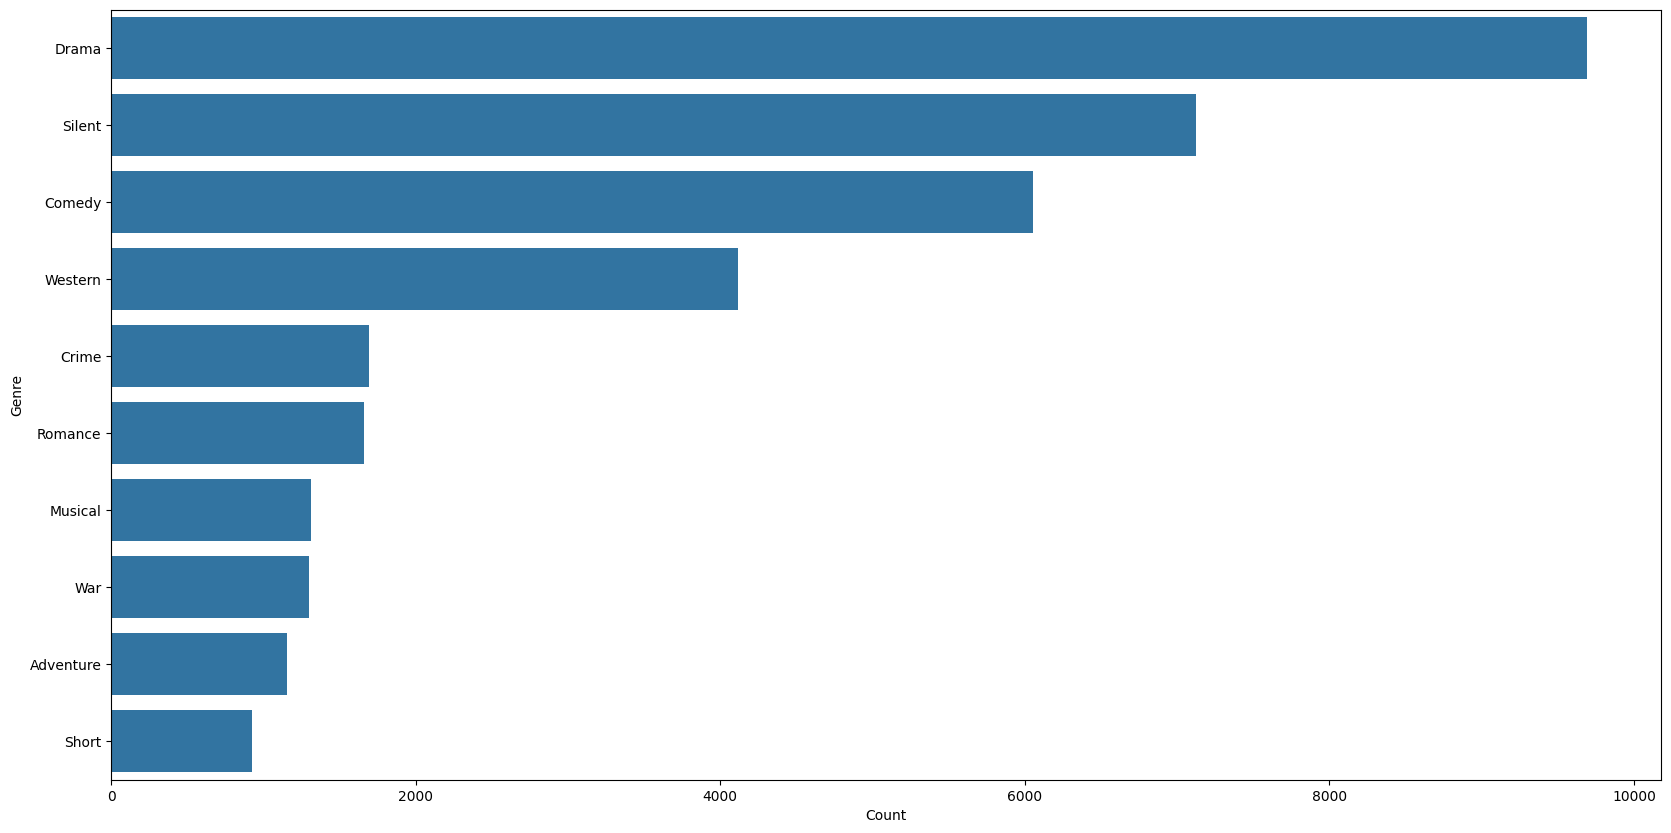

In [ ]:
plt.figure(figsize=(20,10))
sns.barplot(x='Count', y='Genre', data=top10_genres)

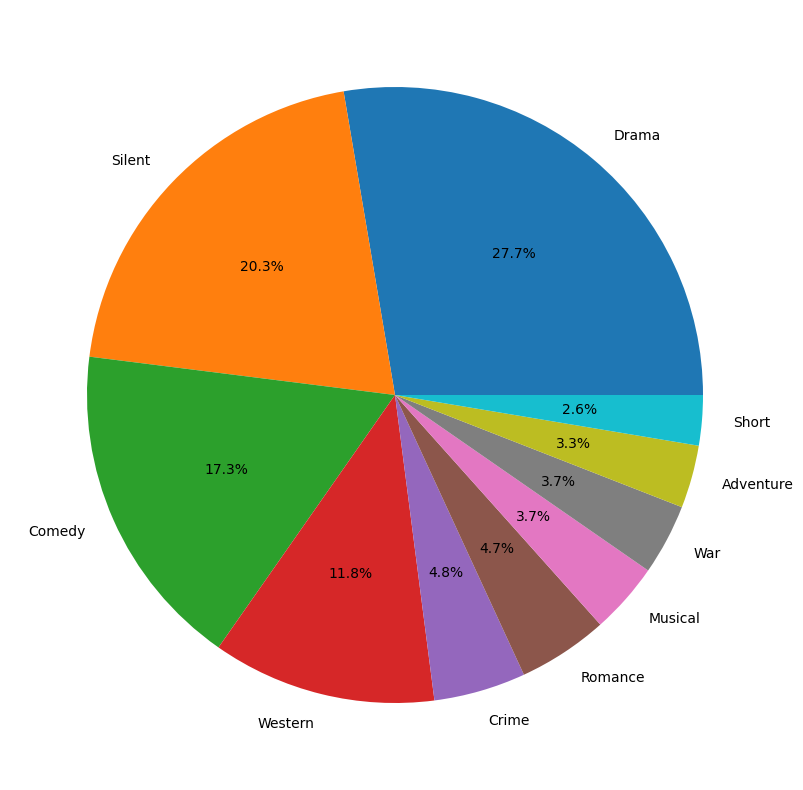

In [ ]:
plt.figure(figsize=(20,10))
plt.pie(top10_genres['Count'], labels=top10_genres['Genre'], autopct='%1.1f%%')
plt.show()

Choose the 3 most popular genres and see how their popularity has changed over time

In [ ]:
top3=df_genres['genres'].value_counts().head(3).index.tolist()
top3

['Drama', 'Silent', 'Comedy']

In [ ]:
df_top3=df_genres[df_genres['genres'].isin(top3)]
genre_counts=df_top3.groupby(['year','genres']).size().reset_index(name='count')
genre_counts

,year,genres,count
0,1900,Comedy,2
1,1900,Silent,6
2,1901,Comedy,1
3,1901,Silent,8
4,1902,Comedy,2
...,...,...,...
170,1968,Comedy,53
171,1968,Drama,58
172,1969,Comedy,46
173,1969,Drama,62


<Axes: xlabel='year', ylabel='count'>

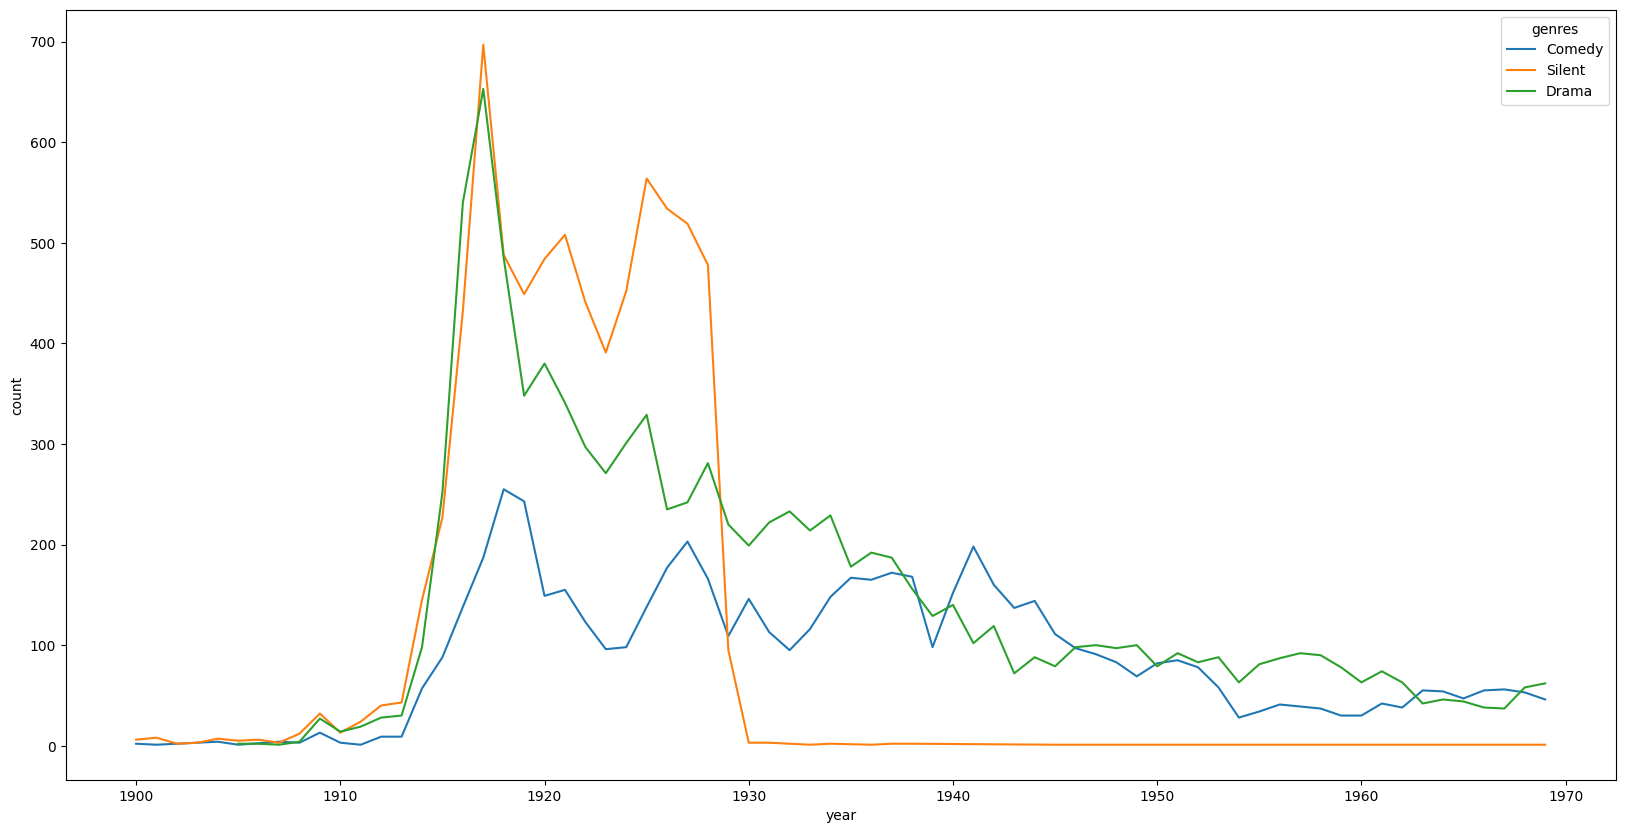

In [ ]:
plt.figure(figsize=(20,10))
sns.lineplot(x='year', y='count', data=genre_counts, hue='genres')

Find the top 10 actors by number of movies.
Construct a bar chart and display a summary table

In [ ]:
df_cast=comb.explode('cast')
df_cast=df_cast.dropna(subset=['cast'])
top10_actors=df_cast['cast'].value_counts().head(10)
df_top10_actors=top10_actors.reset_index()
df_top10_actors.columns=['actor', 'count']
df_top10_actors

,actor,count
0,Harold Lloyd,190
1,Hoot Gibson,157
2,Charles Starrett,137
3,Jack Holt,128
4,John Wayne,126
5,Johnny Mack Brown,123
6,Buck Jones,123
7,Bebe Daniels,113
8,William Boyd,105
9,Raymond Hatton,105


<Axes: xlabel='count', ylabel='actor'>

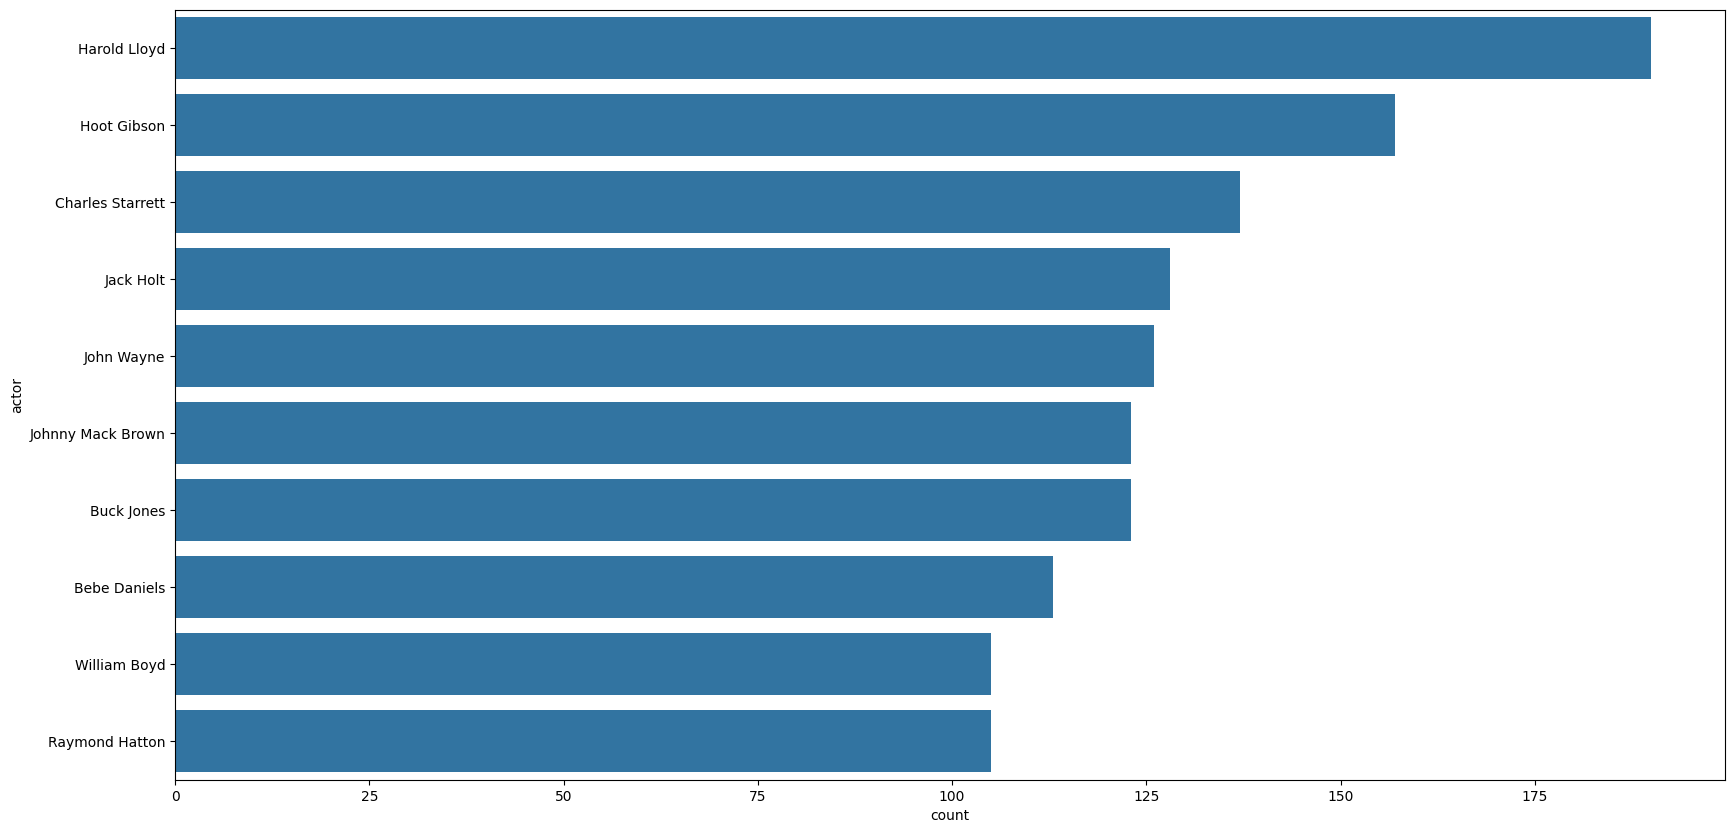

In [ ]:
plt.figure(figsize=(20,10))
sns.barplot(x='count', y='actor', data=df_top10_actors)

Choose the 3 most popular actors and see how their popularity has changed over time

In [ ]:
top3_actors=df_cast['cast'].value_counts().head(3).index.tolist()
for c in top3_actors:
  df[c]=df['cast'].apply(lambda x: 1 if c in x else 0)
actors_by_year=df.groupby('year')[top3_actors].sum()
actors_by_year

,Harold Lloyd,Hoot Gibson,Charles Starrett
year,,,
1900,0,0,0
1901,0,0,0
1902,0,0,0
1903,0,0,0
1904,0,0,0
...,...,...,...
1965,0,0,0
1966,0,0,0
1967,0,0,0


<Figure size 3000x1000 with 0 Axes>

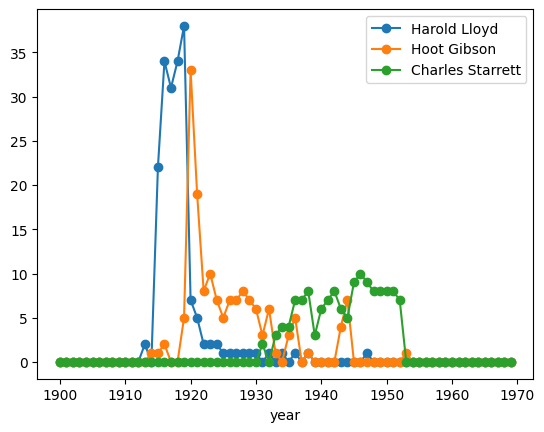

In [ ]:
plt.figure(figsize=(30,10))
actors_by_year.fillna(0).plot(kind='line', marker='o')
plt.show()

Count how often each of the 10 most popular actors appears in a film that belongs to the top 3 most popular genres, and how often in a film that does not include a top genre.
Estimate the proportions for each actor in the form of a bar chart and in the form of a table, which also indicates the percentage of films in the top genres

In [ ]:
top_10_actors=(df_cast['cast'].value_counts().head(10).index.tolist())
comb['top_genre']=comb['genres'].apply(lambda genres: any(g in top3 for g in genres))
result=[]
for actor in top_10_actors:
  actor_movies=comb[comb['cast'].apply(lambda cast: actor in cast)]
  if len(actor_movies)>0:
    top_c=actor_movies['top_genre'].sum()
    non_top_c=len(actor_movies)-top_c
    perc=round((top_c/len(actor_movies)*100),2)
    result.append([actor, top_c, non_top_c, perc])
df_result=pd.DataFrame(result, columns=['Actor', 'Top genres movies', 'Non top movies', 'Top genre %'])
df_result

,Actor,Top genres movies,Non top movies,Top genre %
0,Harold Lloyd,190,0,100.00
1,Hoot Gibson,114,43,72.61
2,Charles Starrett,7,130,5.11
3,Jack Holt,98,30,76.56
4,John Wayne,43,83,34.13
5,Johnny Mack Brown,15,108,12.20
6,Buck Jones,50,73,40.65
7,Bebe Daniels,112,1,99.12
8,William Boyd,31,74,29.52
9,Raymond Hatton,44,61,41.90


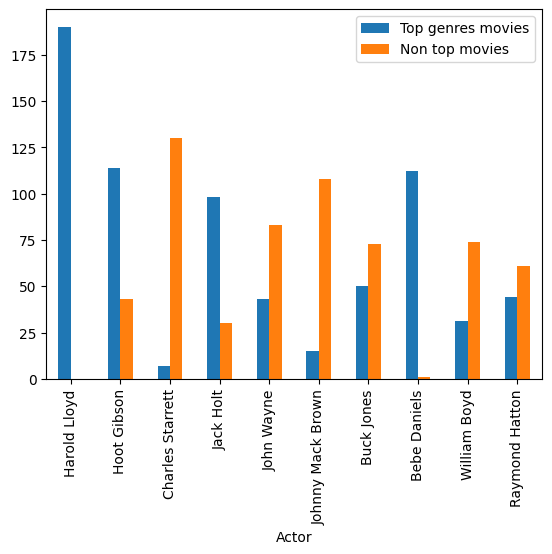

In [ ]:
plot_df=df_result.set_index('Actor')
plot_df[['Top genres movies', 'Non top movies']].plot(kind='bar')
plt.show()